In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical

In [6]:
"""
1000 adet hasta
age: 20-80
gender: K(0)-E(1)
disease: 0(yok),1(hipertansiyon),2(diyabet),3(her ikisi)
semptonlar: ateş + öksürük + baş ağrısı
ateş: 0(yok), 1(hafif), 2(şiddetli)
öksürük: 0(yok), 1(hafif), 2(şiddetli)
baş ağrısı: 0(yok), 1(hafif), 2(şiddetli)
kan basıncı: 90-180
kan şekeri: 70-200
önceki tedavi yanıtı: 0(kötü), 1(iyi)
"""

'\n1000 adet hasta\nage: 20-80\ngender: K(0)-E(1)\ndisease: 0(yok),1(hipertansiyon),2(diyabet),3(her ikisi)\nsemptonlar: ateş + öksürük + baş ağrısı\nateş: 0(yok), 1(hafif), 2(şiddetli)\nöksürük: 0(yok), 1(hafif), 2(şiddetli)\nbaş ağrısı: 0(yok), 1(hafif), 2(şiddetli)\nkan basıncı: 90-180\nkan şekeri: 70-200\nönceki tedavi yanıtı: 0(kötü), 1(iyi)\n'

In [5]:
"""
0(tedavi -1) (basit tedavi): kan basıncı < 120, kan şekeri < 100, semptonlar <=1
0(tedavi -2) (orta tedavi): kan basıncı > 120, kan şekeri < 140, semptonlar ==1
0(tedavi -3) (ileri seviye): kan basıncı > 140, kan şekeri >= 150, semptonlar ==2
"""

'\n0(tedavi -1) (basit tedavi): kan basıncı < 120, kan şekeri < 100, semptonlar <=1\n0(tedavi -2) (orta tedavi): kan basıncı > 120, kan şekeri < 140, semptonlar ==1\n0(tedavi -3) (ileri seviye): kan basıncı > 140, kan şekeri >= 150, semptonlar ==2\n'

In [7]:
def assign_treatment_1(blood_pressure, blood_sugar,symptom):
  return (blood_pressure < 120) & (blood_sugar < 100) & (symptom <= 1)

def assign_treatment_2(blood_pressure, blood_sugar,symptom):
  return (blood_pressure > 120) & (blood_sugar < 140) & (symptom == 1)

def assign_treatment_3(blood_pressure, blood_sugar,symptom):
  return (blood_pressure > 140) & (blood_sugar >= 150) & (symptom == 2)

In [9]:
num_samples = 10000

age = np.random.randint(20, 81, size=num_samples)
gender = np.random.randint(0,2, size=num_samples)
disease = np.random.randint(0,4, size=num_samples)
symptom_fever = np.random.randint(0,3, size=num_samples)
symptom_cough = np.random.randint(0,3, size=num_samples)
symptom_headache = np.random.randint(0,3, size=num_samples)
blood_pressure = np.random.randint(90, 181, size=num_samples)
blood_sugar = np.random.randint(70, 201, size=num_samples)
previous_treatment_response = np.random.randint(0,3, size=num_samples)

In [10]:
symptom = symptom_fever + symptom_cough + symptom_headache


In [11]:
treatment_plan = np.zeros(num_samples)

In [13]:
for i in range(num_samples):
  if assign_treatment_1(blood_pressure[i], blood_sugar[i],symptom[i]):
    treatment_plan[i] = 0 # tedavi 1
  elif assign_treatment_2(blood_pressure[i], blood_sugar[i],symptom[i]):
    treatment_plan[i] = 1 #tedavi 2
  else:
    treatment_plan[i] = 2 #tedavi 3

In [14]:
data = pd.DataFrame({
    'age': age,
    'gender': gender,
    'disease': disease,
    'symptom_fever': symptom_fever,
    'symptom_cough': symptom_cough,
    'symptom_headache': symptom_headache,
    'blood_pressure': blood_pressure,
    'blood_sugar': blood_sugar,
    'previous_treatment_response': previous_treatment_response,
    'symptom': symptom,
    'treatment_plan': treatment_plan
})
data.head()

,age,gender,disease,symptom_fever,symptom_cough,symptom_headache,blood_pressure,blood_sugar,previous_treatment_response,symptom,treatment_plan
0,38,1,0,1,0,1,158,121,2,2,2.0
1,71,0,0,2,2,1,138,180,1,5,2.0
2,53,0,0,1,1,2,167,125,0,4,2.0
3,50,1,2,1,1,1,98,153,1,3,2.0
4,20,0,3,2,2,2,124,198,0,6,2.0


In [15]:
X = data.drop('treatment_plan', axis=1).values
y = to_categorical(data['treatment_plan'],num_classes=3)

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [19]:
model = Sequential(
    [
        Dense(32, activation='relu', input_shape=(X_train.shape[1],)),
        Dense(64, activation='relu'),
        Dense(3, activation='softmax')
    ]
)

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [20]:
history = model.fit(X_train, y_train, epochs=20, batch_size=512, validation_data=(X_test, y_test))

Epoch 1/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.9252 - loss: 0.6689 - val_accuracy: 0.9140 - val_loss: 0.3603
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9335 - loss: 0.2757 - val_accuracy: 0.9385 - val_loss: 0.2468
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9512 - loss: 0.2067 - val_accuracy: 0.9395 - val_loss: 0.2204
Epoch 4/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9466 - loss: 0.2064 - val_accuracy: 0.9395 - val_loss: 0.2138
Epoch 5/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9487 - loss: 0.1942 - val_accuracy: 0.9395 - val_loss: 0.2198
Epoch 6/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9490 - loss: 0.1847 - val_accuracy: 0.9390 - val_loss: 0.1864
Epoch 7/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9459 - loss: 0.1777 - val_accuracy: 0.9395 - val_loss: 0.1808
Epoch 8/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9458 - loss: 0.1660 - val_accuracy: 0.9390 - val_

In [21]:
val_loss ,val_accuracy = model.evaluate(X_test,y_test)
print(f"val_loss: {val_loss}, val_accuracy: {val_accuracy}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9610 - loss: 0.1292
val_loss: 0.13084173202514648, val_accuracy: 0.9580000042915344


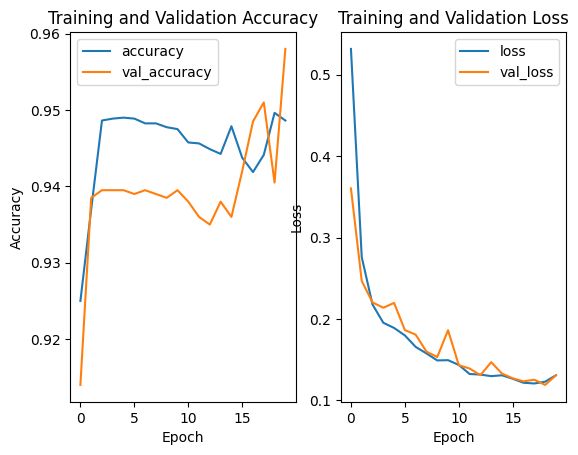

In [24]:
plt.figure()

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.title("Training and Validation Accuracy")
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title("Training and Validation Loss")
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()